# 😷 개인별 건강 취약성 및 방어 행동을 고려한 맞춤형 건강 영향 등급 예측 모델

## 📖 1. 프로젝트 개요 (Context & Problem Statement)
현재 국가 단위의 미세먼지 예보 시스템은 대기 중 오염 물질의 농도(AQI 등)중심으로 일괄적인 정보만을 제공하고 있습니다. 개인이 실제로 느끼는 건강 위험은 연령, 기저질환, 마스크 착용 유무 등에 따라 달라지므로, 본 프로젝트는 **개별적 취약성과 방어 행동을 모델링하여 맞춤형 건강 심각도(Health Impact Class)를 예측**합니다.

## 🎯 2. 핵심 가설 (Hypothesis)
1. **거시적 지표와 미시적 노출의 결합**: 동일한 AQI 상태더라도 도로와의 거리가 가까울수록 초국소적 오염원 노출로 인해 위험 등급이 상승할 것이다.
2. **생물학적 취약성 층화**: 취약 계층(고령자, 환자)은 일반인보다 더 낮은 오염 농도에서도 위험 등급이 급격히 상승하는 임계치를 가질 것이다.
3. **방어 행동의 상쇄 효과**: 고농도 노출 환경에서도 마스크 착용 등의 적극적 행동은 최종 위험 등급을 낮추는 실질적인 방어기제로 작동할 것이다.


# 개인별 건강 취약성 및 방어 행동에 따른 미세먼지 건강 영향 시각화
이 노트북은 `thesis_health_impact_10k.csv` 데이터를 사용하여 주요 가설을 검증합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('thesis_health_impact_10k.csv')
df.head()

,AQI,PM2_5,Age_Group,Preexisting_Condition,Mask_Usage_Rate,Distance_to_Road,HealthImpactScore,HealthImpactClass
0,124.871233,51.458467,1,0,0.298912,848.764212,16.867775,0
1,286.200006,114.443835,0,0,0.094818,499.571873,36.785359,1
2,224.958304,79.375677,0,1,0.126359,203.510955,35.271445,1
3,187.624376,90.468722,1,0,0.180671,739.275369,30.030747,1
4,63.685219,28.211740,1,0,0.203653,424.491354,8.615195,0


### [증명 1] 연령대별 AQI 대비 건강 위험도 (Scatter/Box Plot)
![연령대별 분석](results/plots/01_age_group_boxplot.png)
**[무엇을 증명하는가?]** "동일한 공기질에서도 나이 든 사람은 더 위험하다"는 사실을 입증합니다. 연령대에 따라 건강 점수가 상하로 뚜렷하게 나뉘는 층화 현상을 보여줍니다.

C:\Users\parks\AppData\Local\Temp\ipykernel_19156\2039292864.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age_Group', y='HealthImpactScore', data=df, palette='Set2')


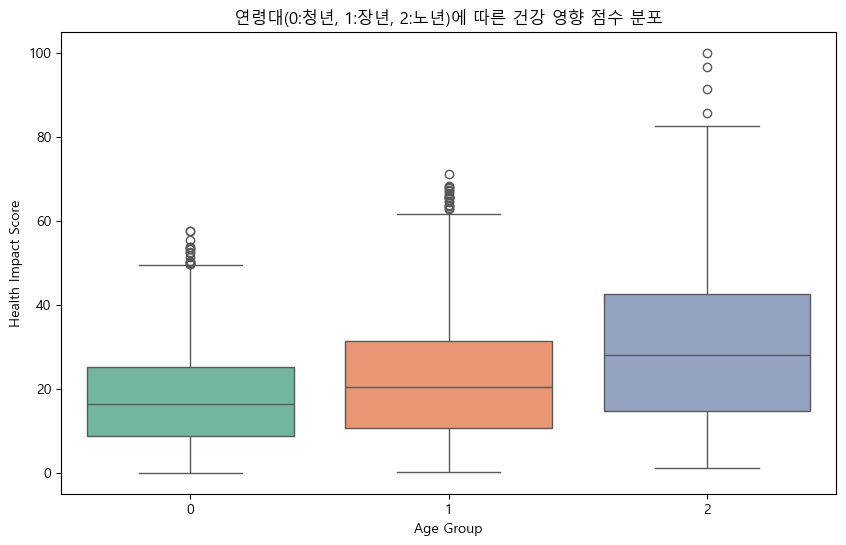

<Figure size 640x480 with 0 Axes>

In [2]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age_Group', y='HealthImpactScore', data=df, palette='Set2')
plt.title('연령대(0:청년, 1:장년, 2:노년)에 따른 건강 영향 점수 분포')
plt.xlabel('Age Group')
plt.ylabel('Health Impact Score')
plt.show()
plt.savefig('results/plots/01_age_group_boxplot.png', dpi=300, bbox_inches='tight')

### [증명 2] 방어 행동에 따른 위험 상쇄 효과 (Box Plot)
![마스크 착용 효과](results/plots/02_mask_usage_boxplot.png)
**[무엇을 증명하는가?]** "마스크가 진짜 효과가 있는가?"를 입증합니다. 마스크 착용 그룹의 위험 등급 분포가 미착용 그룹보다 전체적으로 낮게 형성됨을 시각화합니다.

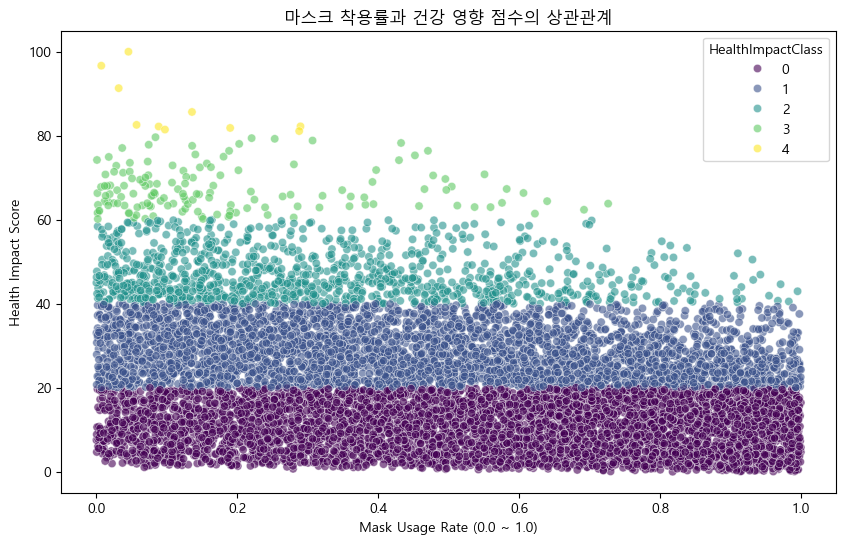

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Mask_Usage_Rate', y='HealthImpactScore', hue='HealthImpactClass', data=df, palette='viridis', alpha=0.6)
plt.title('마스크 착용률과 건강 영향 점수의 상관관계')
plt.xlabel('Mask Usage Rate (0.0 ~ 1.0)')
plt.ylabel('Health Impact Score')
plt.show()

## 3. 요인별 중요도 분석 (생물학적 요인 vs 환경적 요인)

C:\Users\parks\AppData\Local\Temp\ipykernel_19156\3021564683.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='rocket')


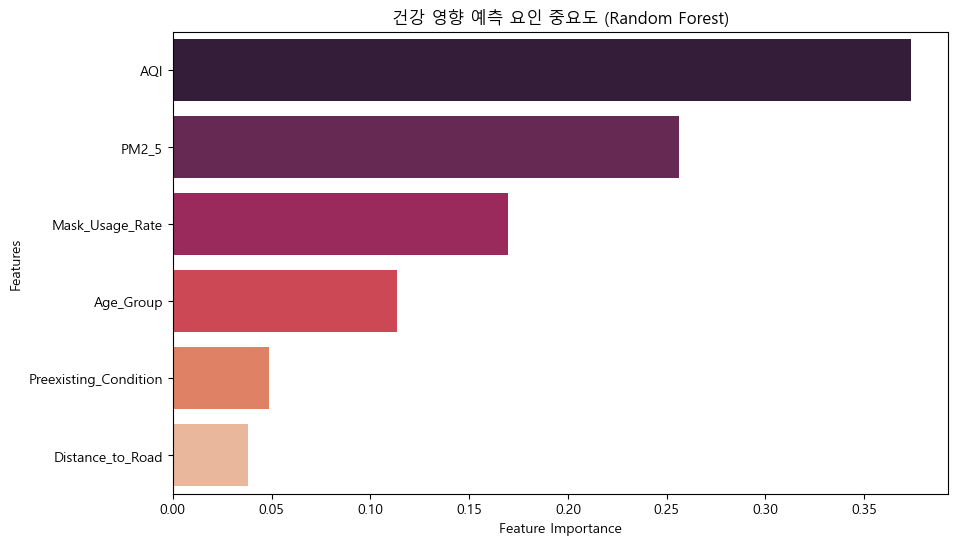

In [4]:
features = ['AQI', 'PM2_5', 'Age_Group', 'Preexisting_Condition', 'Mask_Usage_Rate', 'Distance_to_Road']
target = 'HealthImpactClass'
rf = RandomForestClassifier(random_state=42)
rf.fit(df[features], df[target])

importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, palette='rocket')
plt.title('건강 영향 예측 요인 중요도 (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

## 🤖 5. 머신러닝 예측 모델 (Machine Learning Models) 요약
- **Logistic Regression**: 기본 가중치 파악용 선형 베이스라인 모델
- **Random Forest & XGBoost**: 복잡한 상호작용 포착용 고도화 앙상블 모델

## 📁 6. 프로젝트 산출물 안내 (Project Assets)
- `models/`: 학습 완료된 모델 파일 (*.joblib)
- `results/plots/`: 논문용 고해상도 이미지 (01~07 PNG)
